## Imports and Functions

In [3]:
from recon_functions_all import *
from recon_functions import *
from Analysis import *
from utils import *
import os
from segment_from_projections import find_lungs
import subprocess
import sys
%matplotlib inline

import nibabel as nib
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt


def step_2(main_dir):
    folder1= os.path.join(main_dir,'ct-data','corr')
    corr_dir = os.path.join(main_dir,'ct-data','corr')
    folder2= os.path.join(main_dir,'ct-data','corr_new')
    if not os.path.isdir(folder2): os.mkdir(folder2)
    t = time.time()
    if not os.path.isdir(folder1+'_old'):
        cv(folder1, out_dir=folder2)
        if os.path.exists(folder2):
            os.rename(folder1, folder1+'_old')
            os.rename(folder2,folder1)
    print('Took',round((time.time()-t)/60,2), 'minutes')
    print ('Step 2 is complete') 
def step_3(main_dir, corr_dir, marign = 75, threshold = 0.5):
    sagittal_slice_num, coronal_slice_num = 5000, 2502
    tiff_path = corr_dir+'/proj_000_0_000' +"{:05d}".format(sagittal_slice_num) +'.tif'
    mask_pred, diaphragm_x, diaphragm_y_smooth, diaphragm_height = find_lungs(tiff_path)

    coronal_tiff_path = corr_dir+'/proj_000_0_000' +"{:05d}".format(coronal_slice_num) +'.tif'
    mask_pred_coronal, _, _ , _ = find_lungs(coronal_tiff_path)
    
    try:
        diaphragm_height = int(diaphragm_height)
        xlimits=[diaphragm_height-marign , diaphragm_height+marign] # Default is 350 to 550
    except Exception as e:
        print(f'Error: {e}')
        print('Fall back to using best model (attempt 2)')
        mask_pred, diaphragm_x, diaphragm_y_smooth, diaphragm_height = find_lungs(tiff_path,
                                                                                 CHECKPOINT = r"C:\Users\milabs\Desktop\Pipeline\Rat-lung-segmentation-from-xray\checkpoints\best_model.pt")
        diaphragm_height = int(diaphragm_height)
        xlimits=[diaphragm_height-marign , diaphragm_height] # Default is 350 to 550
        # xlimits=[diaphragm_height-marign , diaphragm_height+marign] # Default is 350 to 550

        mask_pred_coronal, _, _, _ = find_lungs(coronal_tiff_path,
                                                CHECKPOINT = r"C:\Users\milabs\Desktop\Pipeline\Rat-lung-segmentation-from-xray\checkpoints\best_model.pt")
        
        
    threshold = 0.5  # you can adjust the threshold as well; default 0.5
    # -------------------------------------------------------------------------------
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    im = get_image(corr_dir, slice_num=coronal_slice_num, normalize=True, threshold=.5)
    
    plt.imshow(im, cmap='gray')
    plt.imshow(mask_pred_coronal, cmap="jet", alpha=0.25 * mask_pred, vmin=0, vmax=1)
    plt.axhline(y=diaphragm_height, color="green", linewidth=2.5)
    plt.axhline(y=xlimits[0], c = 'r', linestyle = '--')
    plt.axhline(y=xlimits[1], c= 'r', linestyle = '--')
    
    plt.subplot(1,2,2)
    im = get_image(corr_dir, slice_num=sagittal_slice_num, normalize=True, threshold=threshold)
    plt.imshow(im, cmap='gray')
    plt.imshow(mask_pred, cmap="jet", alpha=0.25 * mask_pred, vmin=0, vmax=1)
    plt.plot(diaphragm_x, diaphragm_y_smooth, color="yellow", linewidth=2.5, label="diaphragm (lung inferior border)")
    plt.axhline(y=diaphragm_height, color="green", linewidth=2.5)
    plt.axhline(y=xlimits[0], c = 'r', linestyle = '--')
    plt.axhline(y=xlimits[1], c= 'r', linestyle = '--')
    plt.savefig(os.path.join(main_dir, 'MI_Rat_window_result.png'), dpi=100, bbox_inches='tight')
    plt.show()
    return xlimits
def step_4(main_dir, xlimits, threshold):
    ts = time.time()
    s,t,a = get_signal_from_image(os.path.join(main_dir,'ct-data','corr'),  subtract_baseline = 1,
                                  spring=False, rabbit=False, xlimits=xlimits, threshold=threshold)#, rabbit = True ; if rabbit
    print(f'Took {round((time.time()-ts)/60, 2)} minutes.')
    plt.figure(figsize=(7,4))
    plt.plot(t,s)
    plt.show()
    plt.figure(figsize=(7,4))
    b = fancy_binning(a,s,t , flip_signal=False, only_phase_binning=0)
    b.nbins=16
    b.max_freq = 100
    b.binning(plot=1, withline=True);
    plt.xlim([-0.05,1.05]) ; plt.ylim([-0.05,1.2])
    plt.savefig(os.path.join(main_dir, 'clustering_result.png'), dpi=100, bbox_inches='tight')
    b.get_approximate_breathing_rate()
    plt.show()
    return s,t,a

def MI_reconstruction(main_dir):
    threshold = 0.5
    # step 0
    corr_dir = os.path.join(main_dir,'ct-data','corr')
    check_timing(main_dir)
    # step 2
    step_2(main_dir)
    # Step 3
    xlimits = step_3(main_dir, corr_dir, threshold = threshold)
    # Step 4
    s,t,a = step_4(main_dir, xlimits, threshold)
    # Step 5
    create_milab_structure(main_dir, 
                           intensity_phases=10,
                           time_phases=16,
                          spring = False,
                          s = s,t=t,a=a,
                          only_phase_binning=0,
                          fancy = 1, 
                          optim_SNR = False,
                          bm3d = False,
                          outname=outname,
                          phase = -1,
                          identifier= '',
                          impute = True)
    # Step 6
    root_dir = os.path.join(main_dir, outname)
    recon(root_dir)
    # Step 7 
    collect_results(main_dir, bm3d = False, mname=outname)
    make_gif(main_dir, outname, aslice=260, origin= 'lower') # lower
    return 

def recon(ROOT_DIR):
    PIPELINE_DIR = r"C:\Users\milabs\Desktop\Pipeline"
    BAT_PATH = os.path.join(PIPELINE_DIR, "recon_phase.bat")
    # Extra args forwarded to milabs_rtk_recon.py, e.g. ["--downsample", "4", "--vol-scale", "4"]
    EXTRA_ARGS = []
    if not os.path.isdir(ROOT_DIR):
        raise FileNotFoundError(f"root dir does not exist: {ROOT_DIR}")
    cmd = [BAT_PATH, ROOT_DIR, *EXTRA_ARGS]
    process = subprocess.Popen(
        cmd,
        cwd=PIPELINE_DIR,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    
    for line in process.stdout:
        print(line, end="")
        sys.stdout.flush()
    
    returncode = process.wait()
    print(f"\nExit code: {returncode}")
    return returncode

from register_phases import register_all_phases
def register_step(main_dir, outname, EE_toEI_only=False):
    """Register reconstructed phases onto R0 via yi2.sh.

    EE_toEI_only=True registers only R7->R0 (end-expiration to end-inspiration).
    Otherwise every phase found in the Results folder is registered onto R0.
    Returns the list of phases that failed (empty list = full success).
    """
    results_dir = os.path.join(main_dir, outname, 'Results')
    registered_dir = os.path.join(results_dir, 'Registered')
    os.makedirs(registered_dir, exist_ok=True)

    only_phases = [7] if EE_toEI_only else None
    failures = register_all_phases(results_dir, only_phases=only_phases)
    if failures:
        print(f"Failed phases: {failures}")
    return failures
    
def get_difformation_fields(main_dir, outname,
                            PHASE = 7,
                            ARROW_SIZE_SCALE = 6,        # cone length = ARROW_SIZE_SCALE * magnitude (sizemode="scaled"),
                            MIN_VOXELS_PER_ARROW = 6   # skip blocks with too few lung voxels (e.g. right at the mask edge)
                           ):
    # --- tunable: bigger ARROW_BLOCK -> larger regions per arrow -> fewer arrows ---
    ARROW_BLOCK = 25            # edge length (voxels) of each averaging block
    
    
    COLOR_MIN_MM = 0            # fixed color-scale range for the cones (mm), independent of this run's actual min/max
    COLOR_MAX_MM = 6            # - keeps color meaning consistent when comparing across phases/datasets
    DENSE_STRIDE = 2            # background scatter density only; 1 = every lung voxel, can crash WebGL (see markdown above)

    # Prepare file names
    RESULTS_DIR = os.path.join(main_dir, outname, "Results")
    Registered_dir = os.path.join(RESULTS_DIR, "Registered")
    if not os.path.isdir(Registered_dir) or not os.listdir(Registered_dir):
        raise FileNotFoundError(f"No registered phases found in {Registered_dir} yet - run register_step first.")

    # only consider actual subdirectories, and only ones matching the expected naming
    # pattern, so stray files (.DS_Store, logs, etc.) or extra folders don't get picked
    candidate_dirs = sorted(
        d for d in os.listdir(Registered_dir)
        if os.path.isdir(os.path.join(Registered_dir, d)) and "_to_" in d
    )
    if not candidate_dirs:
        raise FileNotFoundError(
            f"No folders matching '*_to_*' found in {Registered_dir} - run register_step first."
        )
    folder_name = candidate_dirs[0]
    fix_phase = int(folder_name.split('_to_')[-1].split('R')[-1])

    out_dir = os.path.join(Registered_dir, f"R{PHASE}_to_R{fix_phase}")
    if not os.path.isdir(out_dir):
        raise FileNotFoundError(f"Expected registration output folder not found: {out_dir}")

    warp_candidates = [os.path.join(out_dir, x) for x in os.listdir(out_dir) if "Forward.nii.gz" in x]
    if not warp_candidates:
        raise FileNotFoundError(f"No '*Forward.nii.gz' warp file found in {out_dir}")
    warp_path = warp_candidates[0]

    mask_candidates = [os.path.join(RESULTS_DIR, x) for x in os.listdir(RESULTS_DIR) if f"R{PHASE}_m.nii" in x]
    if not mask_candidates:
        raise FileNotFoundError(f"No mask file matching 'R{PHASE}_m.nii*' found in {RESULTS_DIR}")
    mask_path = mask_candidates[0]

    html_out = os.path.join(out_dir, "deformation_field.html")

    # Read images
    warp_img = nib.load(warp_path)
    mask_img = nib.load(mask_path)
    affine = warp_img.affine
    warp = warp_img.get_fdata().squeeze()
    mask = mask_img.get_fdata() != 0
    assert warp.shape[:3] == mask.shape, "warp field and mask are on different grids"
    mag = np.linalg.norm(warp, axis=-1)  # Dense Magnitude

    ## Code
    # all lung voxels - arrow averaging always uses every one of these, independent of DENSE_STRIDE
    ai, aj, ak = np.where(mask)
    if ai.size == 0:
        raise ValueError(f"Mask {mask_path} is empty - no lung voxels found.")

    # average the displacement vector (and position) over blocks of ARROW_BLOCK^3 voxels,
    # so each arrow represents a whole region instead of one sampled point
    block_id = np.stack([ai // ARROW_BLOCK, aj // ARROW_BLOCK, ak // ARROW_BLOCK], axis=1)
    uniq_blocks, inverse = np.unique(block_id, axis=0, return_inverse=True)
    vecs_all = warp[ai, aj, ak, :]
    n_blocks = len(uniq_blocks)
    vec_sums = np.zeros((n_blocks, 3))
    idx_sums = np.zeros((n_blocks, 3))
    counts = np.zeros(n_blocks)
    np.add.at(vec_sums, inverse, vecs_all)
    np.add.at(idx_sums, inverse, np.stack([ai, aj, ak], axis=1).astype(float))
    np.add.at(counts, inverse, 1)
    keep_blocks = counts >= MIN_VOXELS_PER_ARROW
    mean_vecs = vec_sums[keep_blocks] / counts[keep_blocks, None]
    mean_idx = idx_sums[keep_blocks] / counts[keep_blocks, None]

    if len(mean_idx) == 0:
        raise ValueError(
            f"No blocks passed MIN_VOXELS_PER_ARROW={MIN_VOXELS_PER_ARROW}; "
            "lower this threshold or check the mask."
        )

    print(f"averaged arrows: {len(mean_idx):,} (out of {n_blocks:,} candidate blocks)")
    arrow_vox = np.concatenate([mean_idx, np.ones((len(mean_idx), 1))], axis=1)
    arrow_world = (affine @ arrow_vox.T).T[:, :3]

    # background scatter: every lung voxel (or thinned by DENSE_STRIDE), plain gray -
    # it's context only now, the cones carry the actual magnitude/direction data
    di, dj, dk = ai, aj, ak
    if DENSE_STRIDE > 1:
        dkeep = (di % DENSE_STRIDE == 0) & (dj % DENSE_STRIDE == 0) & (dk % DENSE_STRIDE == 0)
        di, dj, dk = di[dkeep], dj[dkeep], dk[dkeep]
    dense_vox = np.stack([di, dj, dk, np.ones_like(di)], axis=1).astype(float)
    dense_world = (affine @ dense_vox.T).T[:, :3]
    print(f"scatter points: {len(di):,}")

    fig_new = go.Figure()
    fig_new.add_trace(go.Scatter3d(
        x=dense_world[:, 0], y=dense_world[:, 1], z=dense_world[:, 2],
        mode="markers",
        marker=dict(size=2, color="gray", opacity=0.4),
        name="lung"))
    fig_new.add_trace(go.Cone(
        x=arrow_world[:, 0], y=arrow_world[:, 1], z=arrow_world[:, 2],
        u=mean_vecs[:, 0], v=mean_vecs[:, 1], w=mean_vecs[:, 2],
        colorscale="jet", sizemode="scaled", sizeref=ARROW_SIZE_SCALE,
        cmin=COLOR_MIN_MM, cmax=COLOR_MAX_MM,
        colorbar=dict(title="mm", x=0.85),
        name="region-averaged direction"))

    # dark theme: both this HTML export and the rotating GIF below reuse this same
    # fig_new object, so styling it once here covers both outputs
    DARK_BG = "black"
    SHOW_AXES = False  # toggle grid lines, ticks, axis labels, and axis titles on the 3D scene
    AXIS_STYLE = dict(backgroundcolor=DARK_BG, gridcolor="dimgray", zerolinecolor="dimgray",
                       color="white", visible=SHOW_AXES)
    fig_new.update_layout(
        scene=dict(aspectmode="data",
                   xaxis=dict(title="X (mm)", **AXIS_STYLE),
                   yaxis=dict(title="Y (mm)", **AXIS_STYLE),
                   zaxis=dict(title="Z (mm)", **AXIS_STYLE),
                   bgcolor=DARK_BG),
        paper_bgcolor=DARK_BG,
        font=dict(color="white"),
        title=f"R{PHASE}\u2192R{fix_phase} displacement magnitude with region-averaged direction arrows",
        width=1000, height=900)
    fig_new.update_traces(
        colorbar=dict(title=dict(text="mm", font=dict(color="white")), tickfont=dict(color="white")),
        selector=dict(type="cone"))
    fig_new.write_html(html_out)
    print("standalone interactive copy saved to:", html_out)
    
outname = 'Optimized_Reconstruction-MI'

## Step 0: Find folder that you want to reconstruct

In [4]:
main_dir = r"D:\Data\Txk5\2026-08-06_12h21"

## Step 1: Correct Projections using Milabs reconstruction sotware


## Step 2: Reconstruction


All good!
Took 0.0 minutes
Step 2 is complete
Error: cannot convert float NaN to integer
Fall back to using best model (attempt 2)


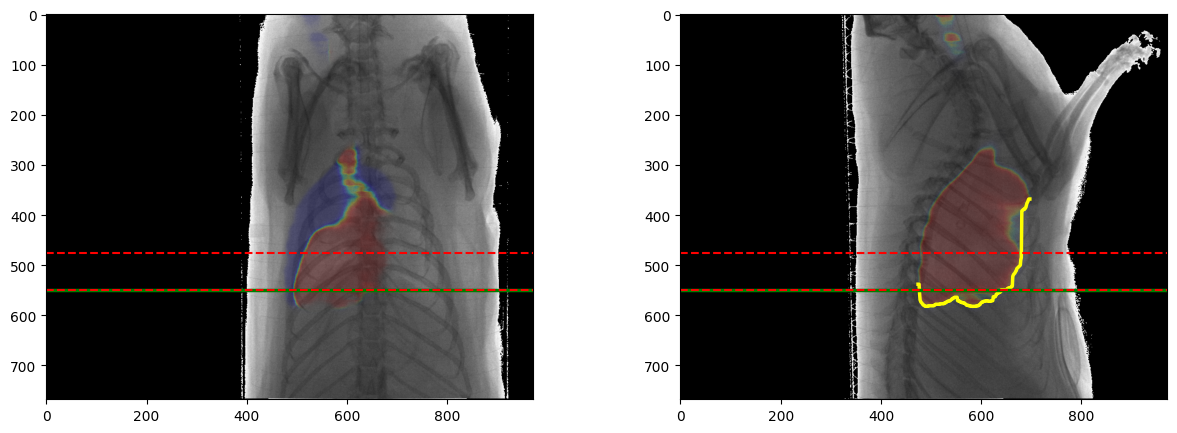

Projections: 100%|██████████████████████████████████████████████████████████████| 11520/11520 [00:52<00:00, 218.31it/s]


Took 0.9 minutes.


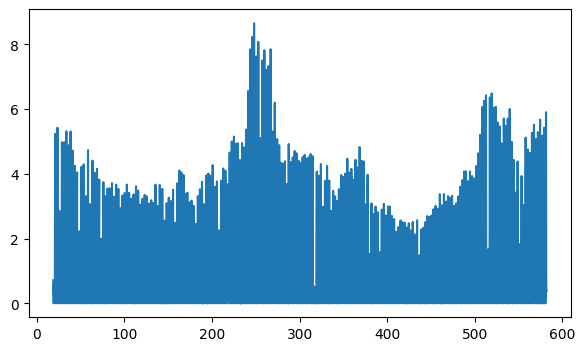

0.0340271 29.388340807174888
Most Representative Breathing Rate: 25.91 BPM


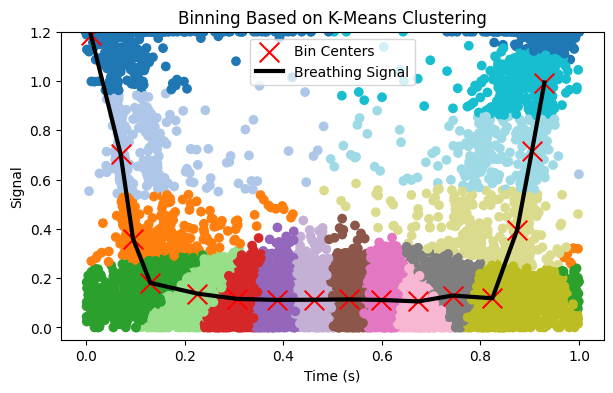

0.0340271 29.388340807174888
Most Representative Breathing Rate: 25.91 BPM


KeyboardInterrupt: 

In [5]:
MI_reconstruction(main_dir) 

## Step 3: Segment

In [ ]:
compress_files(main_dir, outname)
segment(main_dir, outname)
make_gif_cropped(main_dir, outname=outname, vmin = -1150, vmax=350, frame= -1)

## Step 4: Analysis

In [57]:
get_maps(main_dir , outname=outname, overwrite=False)

get_maps             | ############################## | 100.0%


At this point. The analysis is 90% complete.
Generated Maps are in:

    **/Optimized Reconstruction/Results/Maps/maps.png

This maps.png contains FRC and TLC at this point. 

If you want to get the TV, FV, and Jacobian then do the following:

    1) create a folder called "Registration" inside the Results folder. 
    2) Add the "jacobian.npy" and the "registered.npy" inside the "Registration" folder.
    3) Run step 10 again. 

To get the registration files use Mostafa's code on Athena's computer. 

## Register 

In [51]:
register_step(main_dir, outname, EE_toEI_only=True)
get_difformation_fields(main_dir, outname)

Reference: R0 (CT_Phase_0_rtk_R0)   Phases to register: [7]

=== CT_Phase_7_rtk_R7 -> CT_Phase_0_rtk_R0 ===

=== Summary ===
1/1 phases registered successfully
averaged arrows: 186 (out of 193 candidate blocks)
scatter points: 105,063
standalone interactive copy saved to: D:\Data\PhNd10\2026-07-31_12h32\Optimized_Reconstruction-MI\Results\Registered\R7_to_R0\deformation_field.html
